# Домашняя работа 3.

## Подготовка и загрузка.

In [2]:
!pip install jupyterlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 113.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 129.5 MB/s eta 0:00:00


In [3]:
import warnings
for warn in [UserWarning, FutureWarning]: warnings.filterwarnings("ignore", category = warn)

import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import polars as pl
import pandas as pd
import yfinance as yf
import sklearn
import networkx as nx
import jupyterlab as jlab
import ipywidgets
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.mplot3d import Axes3D

In [4]:
ticker = "BTC-USD"
data = yf.download(ticker, start = "2020-01-01", end=pd.Timestamp.now().strftime("%Y-%m-%d"))
data = data[["Close"]]

scaler = MinMaxScaler(feature_range = (0, 1))
scaled_data = scaler.fit_transform(data)


[*********************100%***********************]  1 of 1 completed


## Обработка данных и их разделение.

In [5]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return torch.FloatTensor(X), torch.FloatTensor(y)

seq_length = 60
X, y = create_sequences(scaled_data, seq_length)

train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


## Модель.

In [17]:
class BitcoinGRU(nn.Module):
    def __init__(self, input_size = 1, hidden_size = 32, num_layers = 2):
        super(BitcoinGRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.gru = nn.GRU(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            batch_first = True
        )
        self.fc = nn.Linear(hidden_size, 1).to('cuda')

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).requires_grad_().to('cuda')
        out, hn = self.gru(x, h0.detach())
        out = self.fc(out[:, -1, :])
        return out

In [44]:
model = BitcoinGRU().to('cuda')
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

num_epochs = 20
train_loss = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for i in range(len(X_train)):
        inputs = X_train[i].unsqueeze(0).to('cuda')
        target = y_train[i].unsqueeze(0).to('cuda')

        optimizer.zero_grad()
        output = model(inputs)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(X_train)
    train_loss.append(avg_loss)

    print(f'Epoch {epoch+1} / {num_epochs}, Loss: {avg_loss:.6f}')


Epoch 1 / 20, Loss: 0.000674
Epoch 2 / 20, Loss: 0.001610
Epoch 3 / 20, Loss: 0.001010
Epoch 4 / 20, Loss: 0.000497
Epoch 5 / 20, Loss: 0.000379
Epoch 6 / 20, Loss: 0.000320
Epoch 7 / 20, Loss: 0.000285
Epoch 8 / 20, Loss: 0.000278
Epoch 9 / 20, Loss: 0.000233
Epoch 10 / 20, Loss: 0.000227
Epoch 11 / 20, Loss: 0.000220
Epoch 12 / 20, Loss: 0.000223
Epoch 13 / 20, Loss: 0.000219
Epoch 14 / 20, Loss: 0.000219
Epoch 15 / 20, Loss: 0.000222
Epoch 16 / 20, Loss: 0.000225
Epoch 17 / 20, Loss: 0.000225
Epoch 18 / 20, Loss: 0.000226
Epoch 19 / 20, Loss: 0.000228
Epoch 20 / 20, Loss: 0.000228


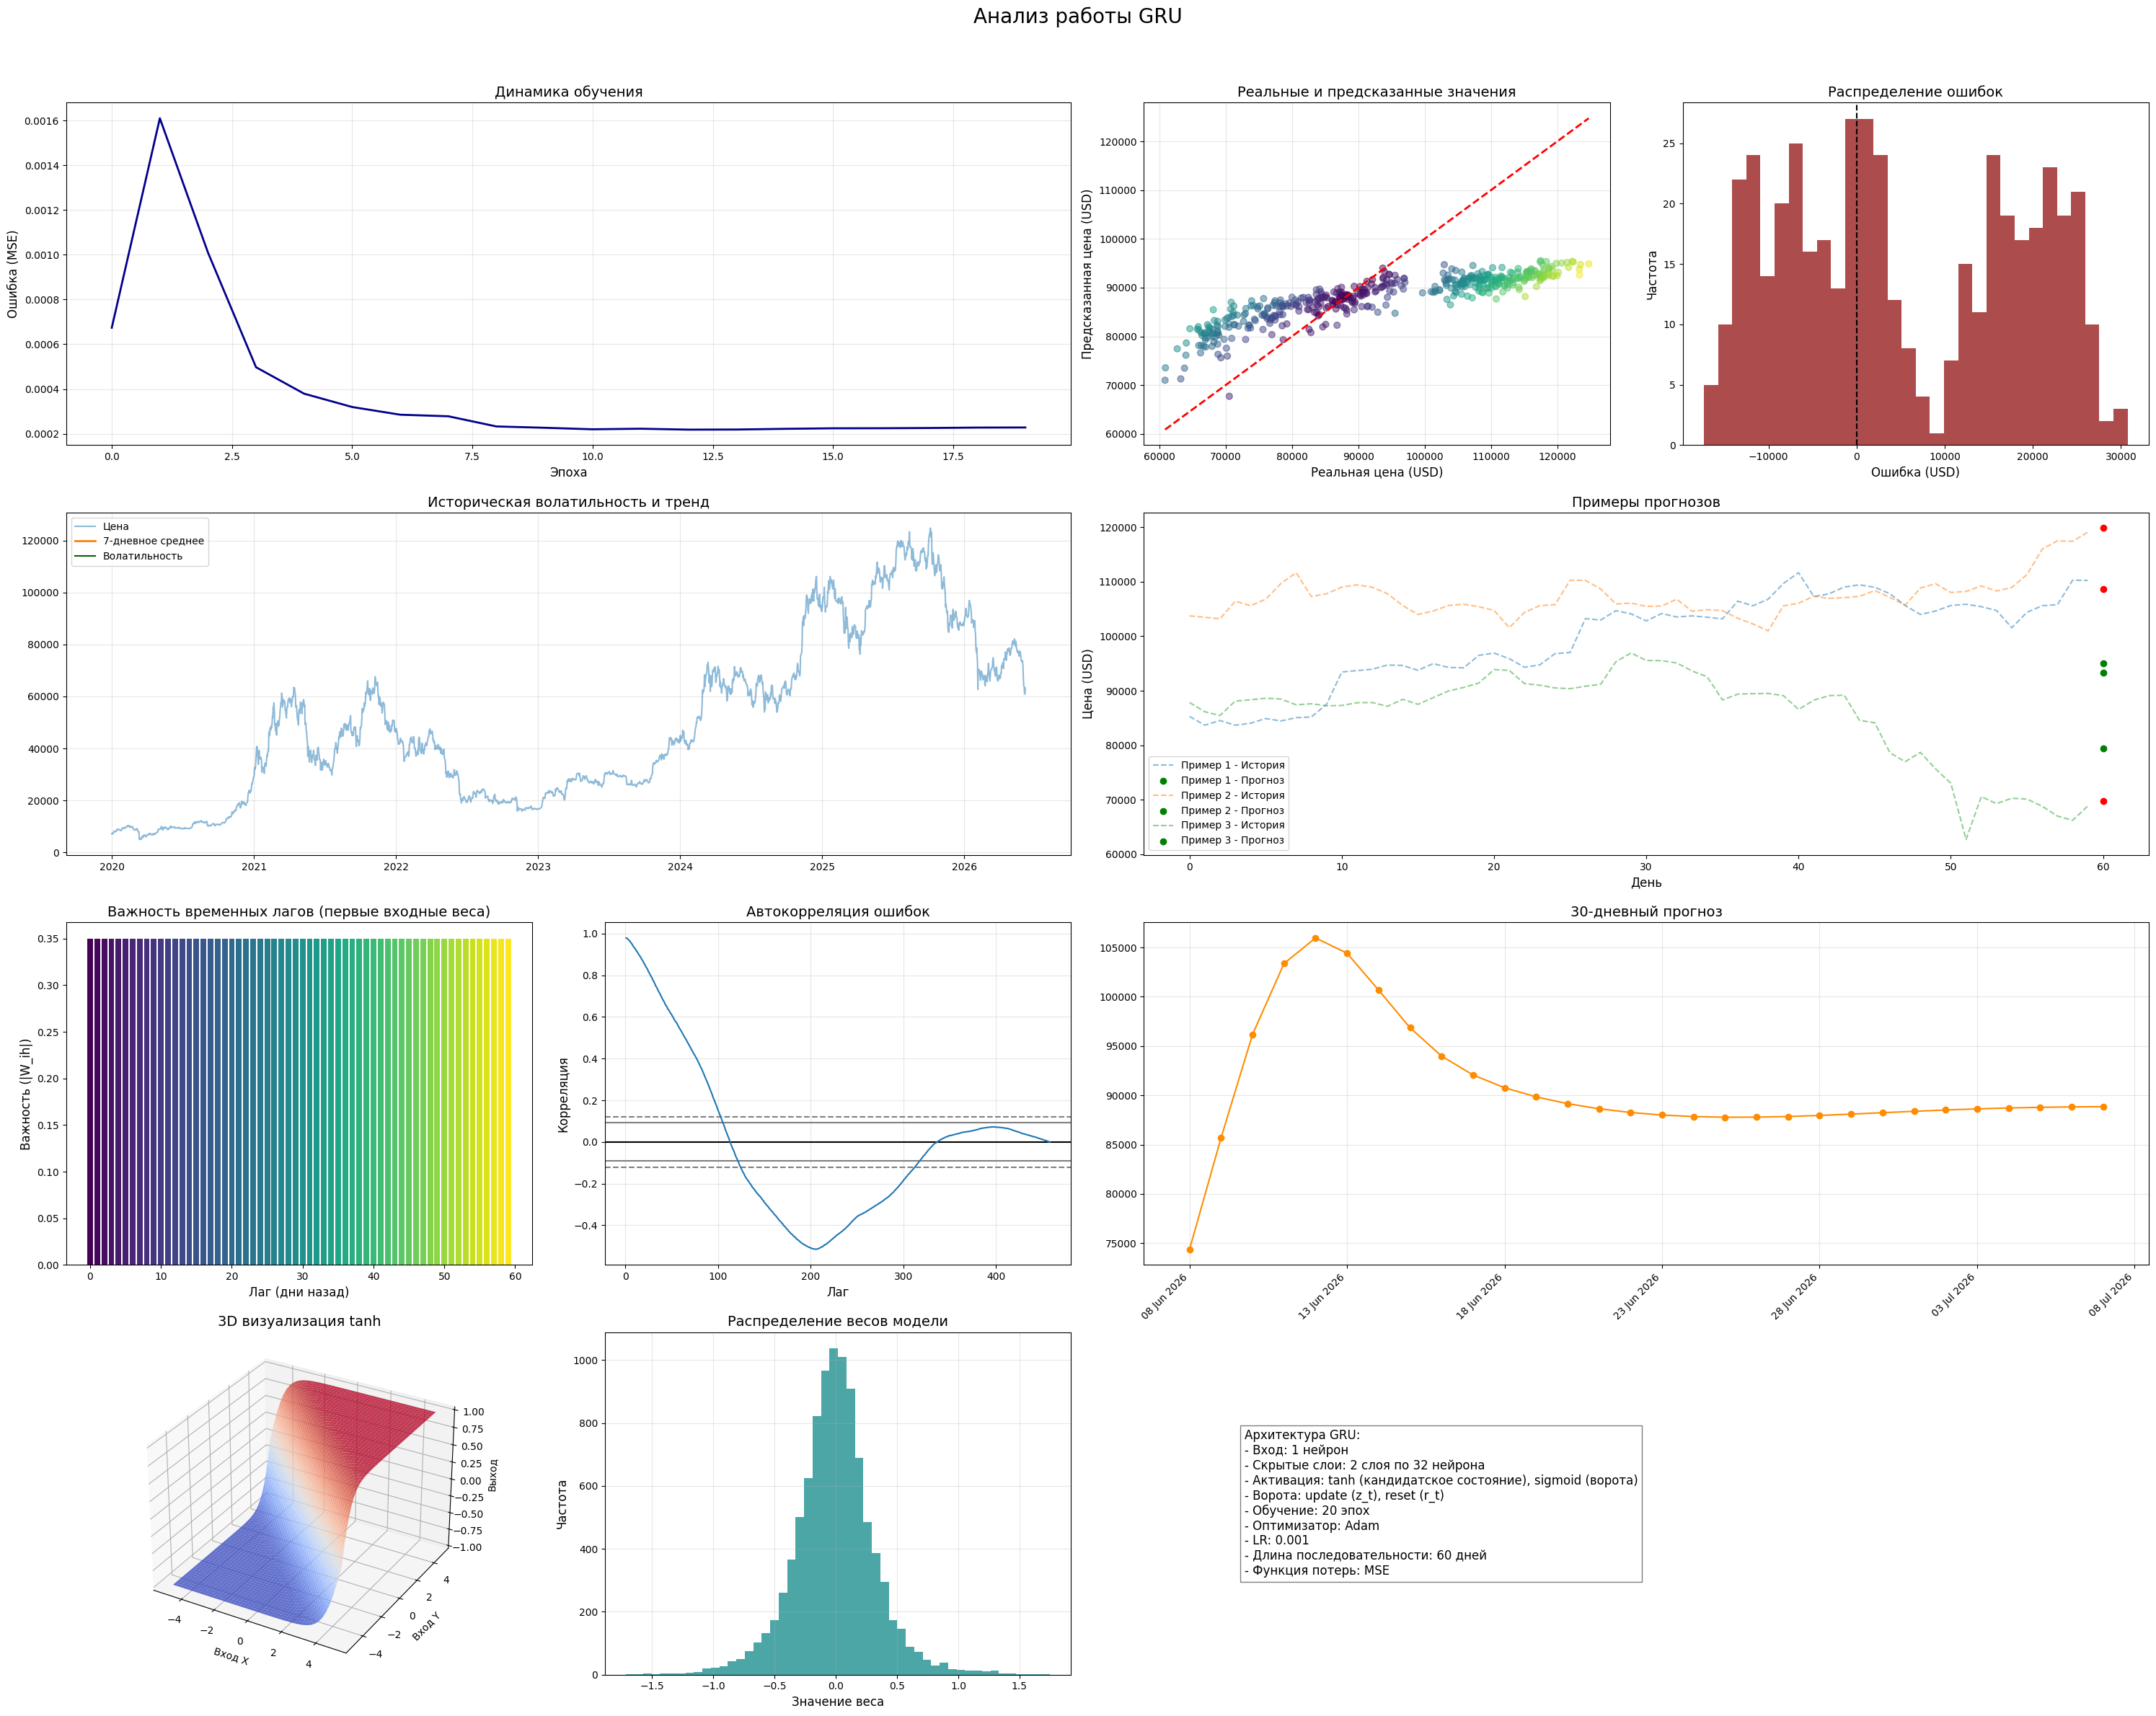

In [45]:
def forecast(model, sequence, days = 30):
    current_seq = sequence.squeeze(0).to('cuda')
    predictions = []
    for _ in range(days):
        pred = model(current_seq.unsqueeze(0))
        predictions.append(pred.item())
        current_seq = torch.cat((current_seq[1:], pred))
    return predictions

last_sequence = scaled_data[-seq_length:]
input_tensor = torch.FloatTensor(last_sequence).unsqueeze(0).to('cuda')
scaled_forecast = forecast(model, input_tensor, days = 30)
forecast_prices = scaler.inverse_transform(np.array(scaled_forecast).reshape(-1, 1))


model.eval()
test_predictions = []
with torch.no_grad():
    for seq in X_test:
        pred = model(seq.unsqueeze(0).to('cuda'))
        test_predictions.append(pred.item())

test_predictions = scaler.inverse_transform(np.array(test_predictions).reshape(-1, 1))
y_test_original = scaler.inverse_transform(y_test.numpy().reshape(-1, 1))

# Создание единой фигуры с subplots
plt.figure(figsize = (30, 25))
plt.suptitle("Анализ работы GRU", y = 0.95, fontsize = 20)

# 1. График обучения
ax1 = plt.subplot2grid((4, 4), (0, 0), colspan = 2)
ax1.plot(train_loss, color = "darkblue", linewidth = 2)
ax1.set_title("Динамика обучения", fontsize = 14)
ax1.set_xlabel("Эпоха", fontsize = 12)
ax1.set_ylabel("Ошибка (MSE)", fontsize = 12)
ax1.grid(True, alpha = 0.3)

# 2. Сравнение реальных и предсказанных значений
ax2 = plt.subplot2grid((4, 4), (0, 2))
ax2.scatter(y_test_original, test_predictions, alpha = 0.5, c = np.abs(y_test_original - test_predictions), cmap = "viridis", s = 40)
ax2.plot([y_test_original.min(), y_test_original.max()], [y_test_original.min(), y_test_original.max()], "--r", linewidth = 2)
ax2.set_title("Реальные и предсказанные значения", fontsize = 14)
ax2.set_xlabel("Реальная цена (USD)", fontsize = 12)
ax2.set_ylabel("Предсказанная цена (USD)", fontsize = 12)
ax2.grid(alpha = 0.3)

# 3. Распределение ошибок
ax3 = plt.subplot2grid((4, 4), (0, 3))
errors = y_test_original - test_predictions
ax3.hist(errors, bins = 30, color = "darkred", alpha = 0.7)
ax3.set_title("Распределение ошибок", fontsize = 14)
ax3.set_xlabel("Ошибка (USD)", fontsize = 12)
ax3.set_ylabel("Частота", fontsize = 12)
ax3.axvline(x = 0, color = "black", linestyle = "--")

# 4. Скользящее среднее и волатильность
ax4 = plt.subplot2grid((4, 4), (1, 0), colspan = 2)
window_size = 7
data["MA_7"] = data["Close"].rolling(window = window_size).mean()
data["Volatility"] = data["Close"].rolling(window = window_size).std()
ax4.plot(data["Close"], label = "Цена", alpha = 0.5)
ax4.plot(data["MA_7"], label = "7-дневное среднее", linewidth = 2)
ax4.plot(data["Volatility"], label = "Волатильность", color = "darkgreen")
ax4.set_title("Историческая волатильность и тренд", fontsize = 14)
ax4.legend()
ax4.grid(alpha = 0.3)

# 5. Примеры прогнозов
ax5 = plt.subplot2grid((4, 4), (1, 2), colspan = 2)
for i in range(3):
    idx = np.random.randint(len(X_test))
    seq = X_test[idx].numpy()
    with torch.no_grad():
        pred = model(X_test[idx].unsqueeze(0).to('cuda'))
    real = scaler.inverse_transform(y_test[idx].numpy().reshape(-1, 1))

    ax5.plot(scaler.inverse_transform(seq), alpha = 0.5, linestyle = "--", label = f"Пример {i+1} - История")
    ax5.scatter(len(seq), real, color = "red", zorder = 5)
    ax5.scatter(len(seq), scaler.inverse_transform(pred.cpu().numpy()), color = "green", zorder = 5, label = f"Пример {i+1} - Прогноз")
ax5.set_title("Примеры прогнозов", fontsize = 14)
ax5.set_xlabel("День", fontsize = 12)
ax5.set_ylabel("Цена (USD)", fontsize = 12)
ax5.legend()

# 6. Важность временных лагов (адаптированная для GRU)
ax6 = plt.subplot2grid((4, 4), (2, 0))
# Получаем веса входного слоя GRU
gru_weights = model.gru.weight_ih_l0.detach().cpu().numpy()
# Средние значения весов по всем нейронам
lag_importance = np.mean(np.abs(gru_weights[:model.hidden_size]), axis = 0)
ax6.bar(range(seq_length), lag_importance[:seq_length], color = plt.cm.viridis(np.linspace(0, 1, seq_length)))
ax6.set_title("Важность временных лагов (первые входные веса)", fontsize = 14)
ax6.set_xlabel("Лаг (дни назад)", fontsize = 12)
ax6.set_ylabel("Важность (|W_ih|)", fontsize = 12)

# 7. Автокорреляция ошибок
ax7 = plt.subplot2grid((4, 4), (2, 1))
pd.plotting.autocorrelation_plot(errors.flatten(), ax = ax7)
ax7.set_title("Автокорреляция ошибок", fontsize = 14)
ax7.set_xlabel("Лаг", fontsize = 12)
ax7.set_ylabel("Корреляция", fontsize = 12)
ax7.grid(alpha = 0.3)

# 8. Долгосрочный прогноз
ax8 = plt.subplot2grid((4, 4), (2, 2), colspan = 2)
forecast_dates = pd.date_range(start = data.index[-1], periods = 31)[1:]
ax8.plot(forecast_dates, forecast_prices, marker = "o", markersize = 6, linestyle = "-", color = "darkorange")
ax8.set_title("30-дневный прогноз", fontsize = 14)
ax8.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
ax8.xaxis.set_major_locator(mdates.DayLocator(interval = 5))
plt.setp(ax8.get_xticklabels(), rotation = 45, ha = "right")
ax8.grid(True, alpha = 0.3)

# 9. 3D визуализация функции активации
ax9 = plt.subplot2grid((4, 4), (3, 0), projection = "3d")
x = np.linspace(-5, 5, 50)
y = np.linspace(-5, 5, 50)
X, Y = np.meshgrid(x, y)
Z = np.tanh(X + Y)
ax9.plot_surface(X, Y, Z, cmap = "coolwarm", alpha = 0.8)
ax9.set_title("3D визуализация tanh", fontsize = 14)
ax9.set_xlabel("Вход X")
ax9.set_ylabel("Вход Y")
ax9.set_zlabel("Выход")

# 10. Распределение весов модели
ax10 = plt.subplot2grid((4, 4), (3, 1))
all_weights = []
for param in model.parameters():
    if param.requires_grad:
        all_weights.extend(param.detach().cpu().numpy().flatten())
ax10.hist(all_weights, bins = 50, color = "teal", alpha = 0.7)
ax10.set_title("Распределение весов модели", fontsize = 14)
ax10.set_xlabel("Значение веса", fontsize = 12)
ax10.set_ylabel("Частота", fontsize = 12)
ax10.grid(True, alpha = 0.3)

# 11. Легенда модели
ax11 = plt.subplot2grid((4, 4), (3, 2), colspan = 2)
ax11.axis("off")
text = """Архитектура GRU:
- Вход: 1 нейрон
- Скрытые слои: 2 слоя по 32 нейрона
- Активация: tanh (кандидатское состояние), sigmoid (ворота)
- Ворота: update (z_t), reset (r_t)
- Обучение: 20 эпох
- Оптимизатор: Adam
- LR: 0.001
- Длина последовательности: 60 дней
- Функция потерь: MSE"""
ax11.text(0.1, 0.5, text, fontsize = 12, va = "center", bbox = dict(facecolor = "white", alpha = 0.5))

plt.tight_layout(rect = [0, 0, 1, 0.93])
plt.show()

## Очевидные эксперименты.

### Мы попробовали стаднартные параметры обучения, однако в моменте видно, что функция потерь начинает снова расти, что может говорить о том, что шаг $lr = 0.001$ слишком большой, поэтому банально попробуем уменьшить шаг, увеличив количество эпох.

Epoch 1 / 40, Loss: 0.000904
Epoch 2 / 40, Loss: 0.003722
Epoch 3 / 40, Loss: 0.002092
Epoch 4 / 40, Loss: 0.000886
Epoch 5 / 40, Loss: 0.000474
Epoch 6 / 40, Loss: 0.000354
Epoch 7 / 40, Loss: 0.000307
Epoch 8 / 40, Loss: 0.000279
Epoch 9 / 40, Loss: 0.000258
Epoch 10 / 40, Loss: 0.000240
Epoch 11 / 40, Loss: 0.000227
Epoch 12 / 40, Loss: 0.000215
Epoch 13 / 40, Loss: 0.000207
Epoch 14 / 40, Loss: 0.000199
Epoch 15 / 40, Loss: 0.000193
Epoch 16 / 40, Loss: 0.000188
Epoch 17 / 40, Loss: 0.000184
Epoch 18 / 40, Loss: 0.000180
Epoch 19 / 40, Loss: 0.000177
Epoch 20 / 40, Loss: 0.000174
Epoch 21 / 40, Loss: 0.000172
Epoch 22 / 40, Loss: 0.000170
Epoch 23 / 40, Loss: 0.000168
Epoch 24 / 40, Loss: 0.000167
Epoch 25 / 40, Loss: 0.000166
Epoch 26 / 40, Loss: 0.000165
Epoch 27 / 40, Loss: 0.000164
Epoch 28 / 40, Loss: 0.000163
Epoch 29 / 40, Loss: 0.000163
Epoch 30 / 40, Loss: 0.000162
Epoch 31 / 40, Loss: 0.000162
Epoch 32 / 40, Loss: 0.000161
Epoch 33 / 40, Loss: 0.000161
Epoch 34 / 40, Loss

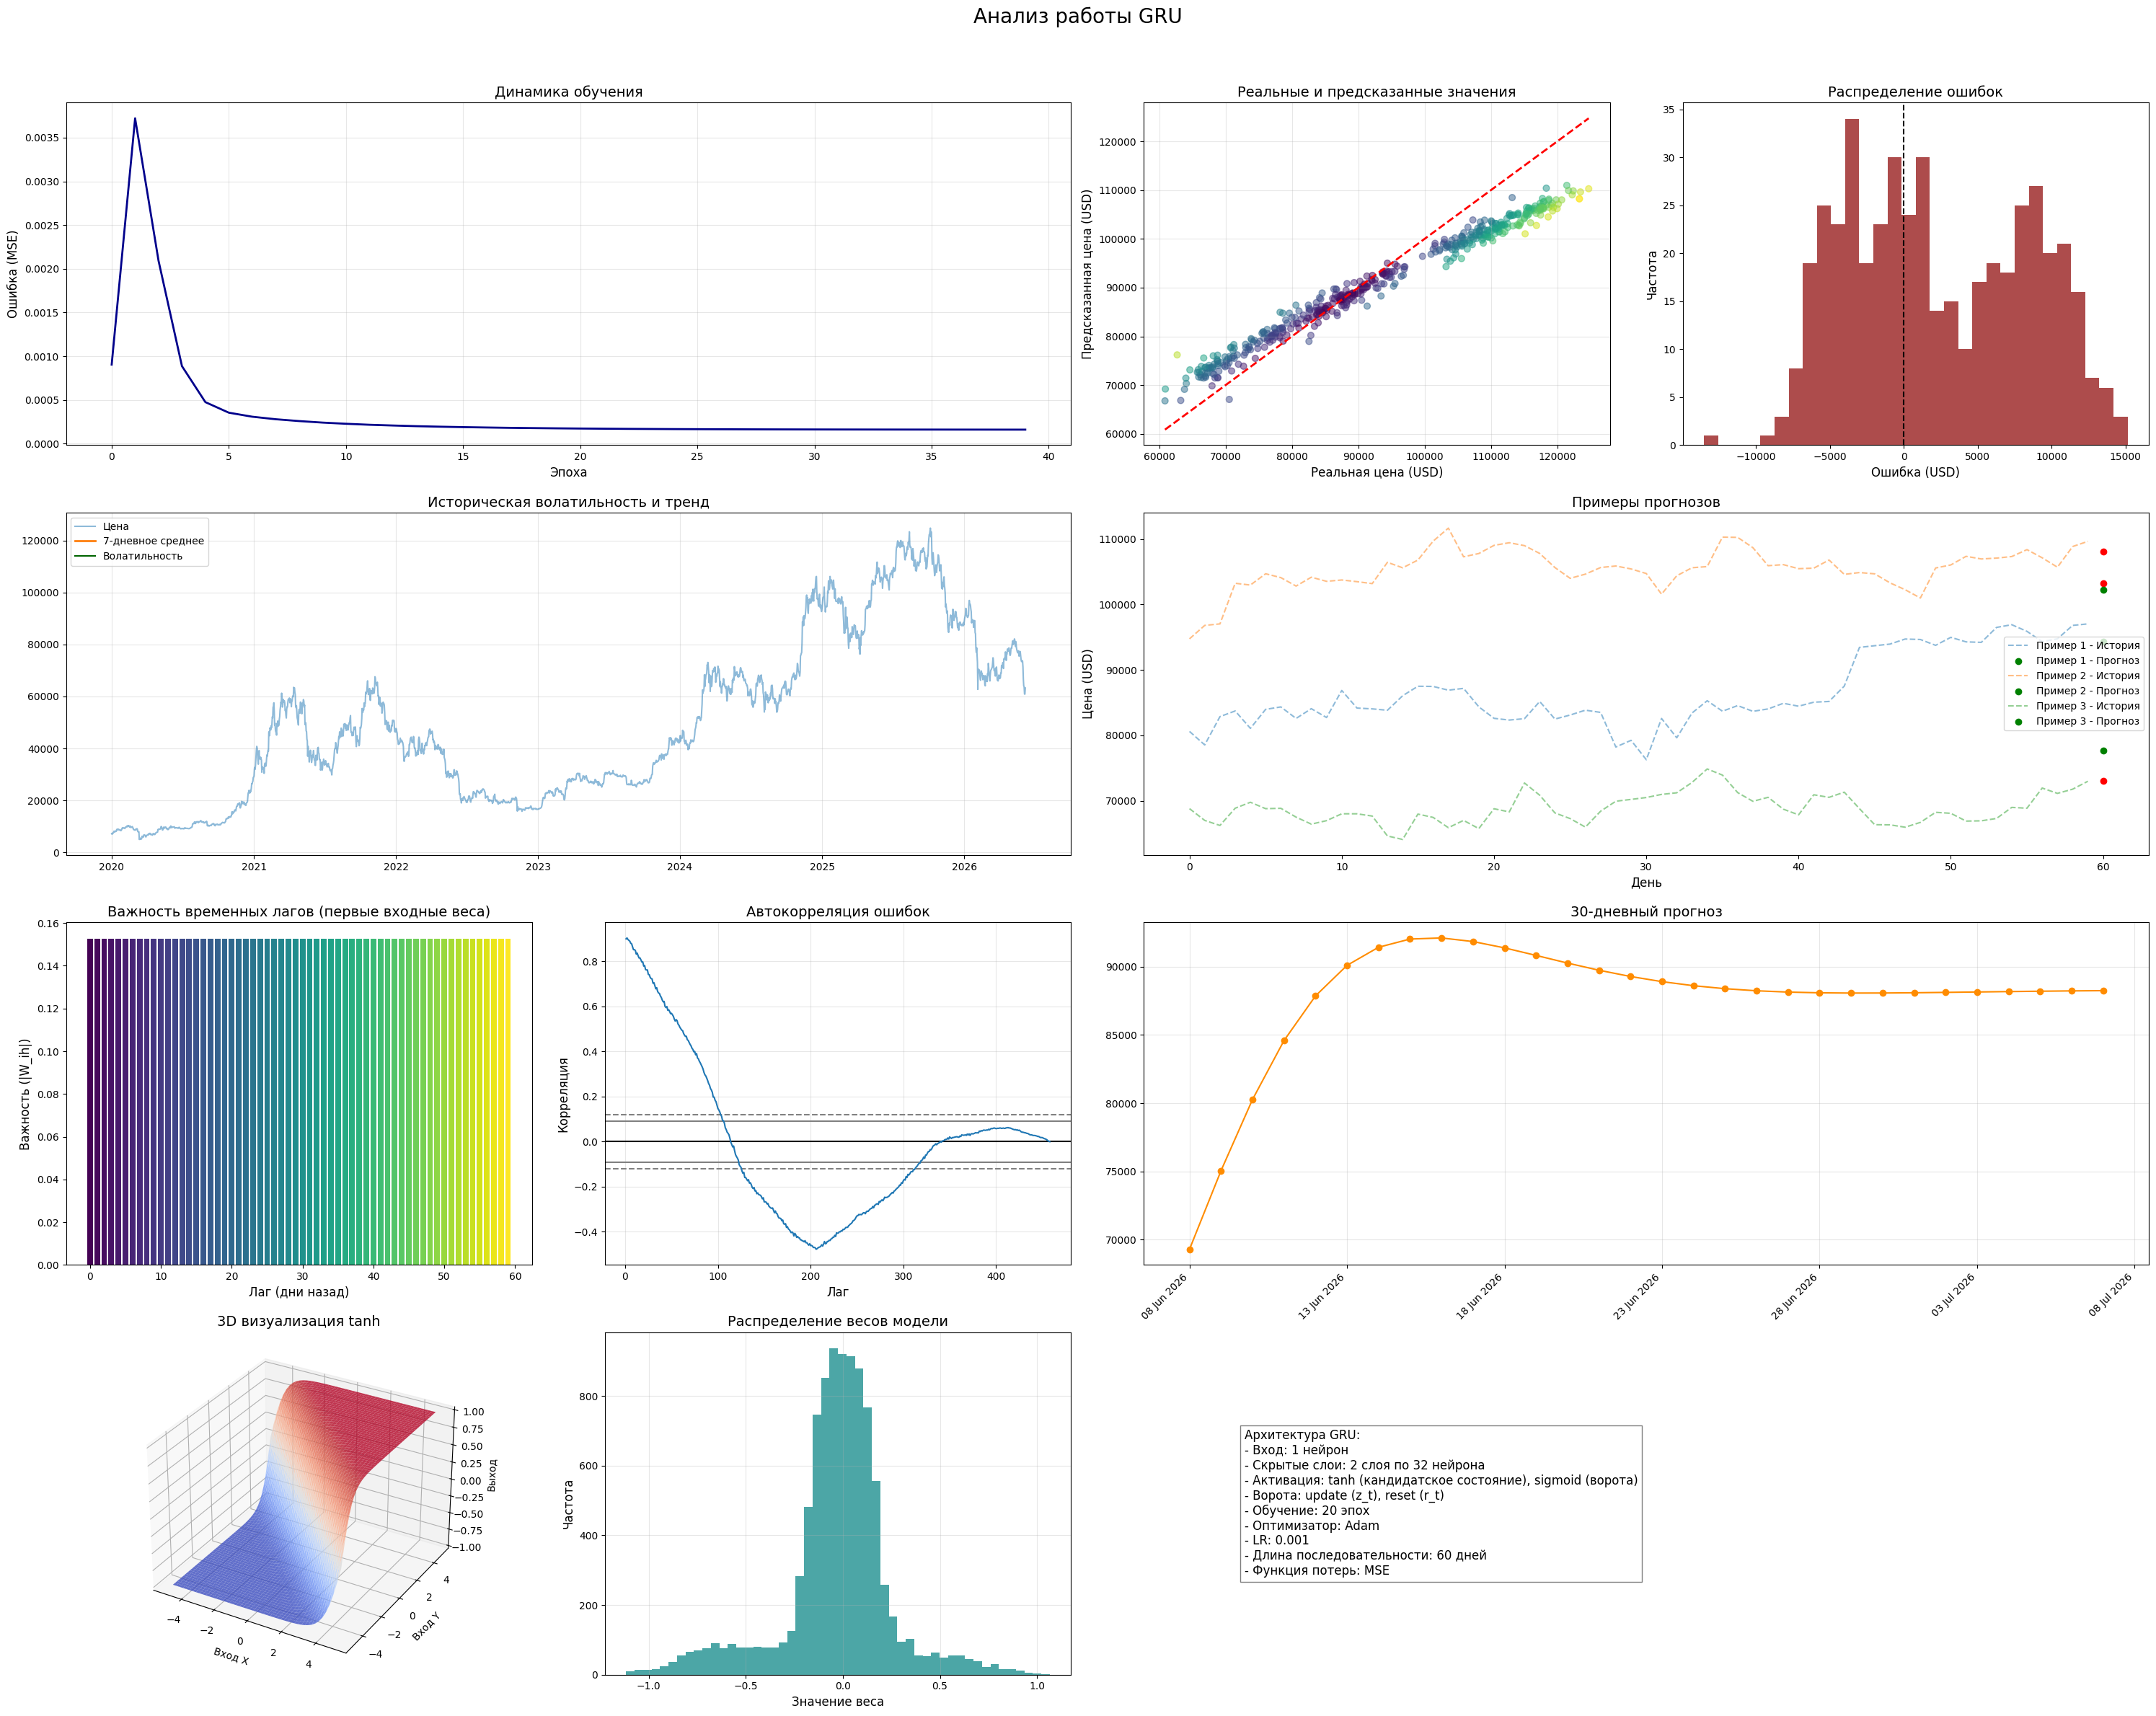

In [47]:
model = BitcoinGRU().to('cuda')
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.0001)

num_epochs = 40
train_loss = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for i in range(len(X_train)):
        inputs = X_train[i].unsqueeze(0).to('cuda')
        target = y_train[i].unsqueeze(0).to('cuda')

        optimizer.zero_grad()
        output = model(inputs)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(X_train)
    train_loss.append(avg_loss)

    print(f'Epoch {epoch+1} / {num_epochs}, Loss: {avg_loss:.6f}')
def forecast(model, sequence, days = 30):
    current_seq = sequence.squeeze(0).to('cuda')
    predictions = []
    for _ in range(days):
        pred = model(current_seq.unsqueeze(0))
        predictions.append(pred.item())
        current_seq = torch.cat((current_seq[1:], pred))
    return predictions

last_sequence = scaled_data[-seq_length:]
input_tensor = torch.FloatTensor(last_sequence).unsqueeze(0).to('cuda')
scaled_forecast = forecast(model, input_tensor, days = 30)
forecast_prices = scaler.inverse_transform(np.array(scaled_forecast).reshape(-1, 1))


model.eval()
test_predictions = []
with torch.no_grad():
    for seq in X_test:
        pred = model(seq.unsqueeze(0).to('cuda'))
        test_predictions.append(pred.item())

test_predictions = scaler.inverse_transform(np.array(test_predictions).reshape(-1, 1))
y_test_original = scaler.inverse_transform(y_test.numpy().reshape(-1, 1))

# Создание единой фигуры с subplots
plt.figure(figsize = (30, 25))
plt.suptitle("Анализ работы GRU", y = 0.95, fontsize = 20)

# 1. График обучения
ax1 = plt.subplot2grid((4, 4), (0, 0), colspan = 2)
ax1.plot(train_loss, color = "darkblue", linewidth = 2)
ax1.set_title("Динамика обучения", fontsize = 14)
ax1.set_xlabel("Эпоха", fontsize = 12)
ax1.set_ylabel("Ошибка (MSE)", fontsize = 12)
ax1.grid(True, alpha = 0.3)

# 2. Сравнение реальных и предсказанных значений
ax2 = plt.subplot2grid((4, 4), (0, 2))
ax2.scatter(y_test_original, test_predictions, alpha = 0.5, c = np.abs(y_test_original - test_predictions), cmap = "viridis", s = 40)
ax2.plot([y_test_original.min(), y_test_original.max()], [y_test_original.min(), y_test_original.max()], "--r", linewidth = 2)
ax2.set_title("Реальные и предсказанные значения", fontsize = 14)
ax2.set_xlabel("Реальная цена (USD)", fontsize = 12)
ax2.set_ylabel("Предсказанная цена (USD)", fontsize = 12)
ax2.grid(alpha = 0.3)

# 3. Распределение ошибок
ax3 = plt.subplot2grid((4, 4), (0, 3))
errors = y_test_original - test_predictions
ax3.hist(errors, bins = 30, color = "darkred", alpha = 0.7)
ax3.set_title("Распределение ошибок", fontsize = 14)
ax3.set_xlabel("Ошибка (USD)", fontsize = 12)
ax3.set_ylabel("Частота", fontsize = 12)
ax3.axvline(x = 0, color = "black", linestyle = "--")

# 4. Скользящее среднее и волатильность
ax4 = plt.subplot2grid((4, 4), (1, 0), colspan = 2)
window_size = 7
data["MA_7"] = data["Close"].rolling(window = window_size).mean()
data["Volatility"] = data["Close"].rolling(window = window_size).std()
ax4.plot(data["Close"], label = "Цена", alpha = 0.5)
ax4.plot(data["MA_7"], label = "7-дневное среднее", linewidth = 2)
ax4.plot(data["Volatility"], label = "Волатильность", color = "darkgreen")
ax4.set_title("Историческая волатильность и тренд", fontsize = 14)
ax4.legend()
ax4.grid(alpha = 0.3)

# 5. Примеры прогнозов
ax5 = plt.subplot2grid((4, 4), (1, 2), colspan = 2)
for i in range(3):
    idx = np.random.randint(len(X_test))
    seq = X_test[idx].numpy()
    with torch.no_grad():
        pred = model(X_test[idx].unsqueeze(0).to('cuda'))
    real = scaler.inverse_transform(y_test[idx].numpy().reshape(-1, 1))

    ax5.plot(scaler.inverse_transform(seq), alpha = 0.5, linestyle = "--", label = f"Пример {i+1} - История")
    ax5.scatter(len(seq), real, color = "red", zorder = 5)
    ax5.scatter(len(seq), scaler.inverse_transform(pred.cpu().numpy()), color = "green", zorder = 5, label = f"Пример {i+1} - Прогноз")
ax5.set_title("Примеры прогнозов", fontsize = 14)
ax5.set_xlabel("День", fontsize = 12)
ax5.set_ylabel("Цена (USD)", fontsize = 12)
ax5.legend()

# 6. Важность временных лагов (адаптированная для GRU)
ax6 = plt.subplot2grid((4, 4), (2, 0))
# Получаем веса входного слоя GRU
gru_weights = model.gru.weight_ih_l0.detach().cpu().numpy()
# Средние значения весов по всем нейронам
lag_importance = np.mean(np.abs(gru_weights[:model.hidden_size]), axis = 0)
ax6.bar(range(seq_length), lag_importance[:seq_length], color = plt.cm.viridis(np.linspace(0, 1, seq_length)))
ax6.set_title("Важность временных лагов (первые входные веса)", fontsize = 14)
ax6.set_xlabel("Лаг (дни назад)", fontsize = 12)
ax6.set_ylabel("Важность (|W_ih|)", fontsize = 12)

# 7. Автокорреляция ошибок
ax7 = plt.subplot2grid((4, 4), (2, 1))
pd.plotting.autocorrelation_plot(errors.flatten(), ax = ax7)
ax7.set_title("Автокорреляция ошибок", fontsize = 14)
ax7.set_xlabel("Лаг", fontsize = 12)
ax7.set_ylabel("Корреляция", fontsize = 12)
ax7.grid(alpha = 0.3)

# 8. Долгосрочный прогноз
ax8 = plt.subplot2grid((4, 4), (2, 2), colspan = 2)
forecast_dates = pd.date_range(start = data.index[-1], periods = 31)[1:]
ax8.plot(forecast_dates, forecast_prices, marker = "o", markersize = 6, linestyle = "-", color = "darkorange")
ax8.set_title("30-дневный прогноз", fontsize = 14)
ax8.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
ax8.xaxis.set_major_locator(mdates.DayLocator(interval = 5))
plt.setp(ax8.get_xticklabels(), rotation = 45, ha = "right")
ax8.grid(True, alpha = 0.3)

# 9. 3D визуализация функции активации
ax9 = plt.subplot2grid((4, 4), (3, 0), projection = "3d")
x = np.linspace(-5, 5, 50)
y = np.linspace(-5, 5, 50)
X, Y = np.meshgrid(x, y)
Z = np.tanh(X + Y)
ax9.plot_surface(X, Y, Z, cmap = "coolwarm", alpha = 0.8)
ax9.set_title("3D визуализация tanh", fontsize = 14)
ax9.set_xlabel("Вход X")
ax9.set_ylabel("Вход Y")
ax9.set_zlabel("Выход")

# 10. Распределение весов модели
ax10 = plt.subplot2grid((4, 4), (3, 1))
all_weights = []
for param in model.parameters():
    if param.requires_grad:
        all_weights.extend(param.detach().cpu().numpy().flatten())
ax10.hist(all_weights, bins = 50, color = "teal", alpha = 0.7)
ax10.set_title("Распределение весов модели", fontsize = 14)
ax10.set_xlabel("Значение веса", fontsize = 12)
ax10.set_ylabel("Частота", fontsize = 12)
ax10.grid(True, alpha = 0.3)

# 11. Легенда модели
ax11 = plt.subplot2grid((4, 4), (3, 2), colspan = 2)
ax11.axis("off")
text = """Архитектура GRU:
- Вход: 1 нейрон
- Скрытые слои: 2 слоя по 32 нейрона
- Активация: tanh (кандидатское состояние), sigmoid (ворота)
- Ворота: update (z_t), reset (r_t)
- Обучение: 20 эпох
- Оптимизатор: Adam
- LR: 0.001
- Длина последовательности: 60 дней
- Функция потерь: MSE"""
ax11.text(0.1, 0.5, text, fontsize = 12, va = "center", bbox = dict(facecolor = "white", alpha = 0.5))

plt.tight_layout(rect = [0, 0, 1, 0.93])
plt.show()

Что ж, это не помогло, потому что модель через неделю перестаёт корректно предсказывать, начиная с определенного момента выдавать просто среднее значенеи в качестве своего предсказания.

#### Теперь попробуем сразу несколько улучшений. Во-первых, немного поменяем обработку наших данных, заменив `MinMaxScaler` на `StandartScaler`, потому что загон значений в диапазон (0, 1) слишком суров. Во-вторых, поменяем немного архитектуру нашей нейросети, для $t$-ого момента будет подавать не просто число, а какую-то дополнительную информацию, например среднее значение до этого момента или ещё что-то. То есть приведём небольшой feature engineering и соответствующие ему изменения самой архитектуры. В-третьих, увеличим размер внутреннего вектора с 32 на 64, а количество слоёв увеличим до трёх. В-четвертых, будем теперь предсказывать не следующий день, а сразу следующие 60 дней, так как прошлые предсказания основывались на последовательном построении предсказания на следующий день, что не учитывает множество нюансов и приводит к некорректным предсказаниям.

Теперь мы подтянем из датасета не одну фичу, но сразу 5. Однако можно пойти ещё дальше и сделать какие-то дополнительные фичи вроде среднего за месяц.

---



In [88]:
from sklearn.preprocessing import StandardScaler
ticker = "BTC-USD"
data = yf.download(ticker, start = "2020-01-01", end=pd.Timestamp.now().strftime("%Y-%m-%d"))
data.columns = data.columns.get_level_values(0)
data['feat_1'] = data['Close'].ewm(span=7, adjust=False).mean()
data['feat_2'] = data['Close'].rolling(window=30).mean()
data['feat_3'] = data['Close'].rolling(window=7).std()
data = data.dropna()
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
scaled_data, data.columns


[*********************100%***********************]  1 of 1 completed


(array([[-1.28947607, -1.2985773 , -1.28535877, ..., -1.30222077,
         -1.31662311, -0.82376331],
        [-1.29456991, -1.29957233, -1.28536272, ..., -1.30006394,
         -1.31431435, -0.85344372],
        [-1.2932087 , -1.3021813 , -1.28266915, ..., -1.29810567,
         -1.3117296 , -0.95814155],
        ...,
        [ 0.363222  ,  0.42257422,  0.34386203, ...,  0.54630611,
          0.84761159,  3.56134129],
        [ 0.36144586,  0.3462582 ,  0.35652614, ...,  0.50076382,
          0.82705887,  3.36153735],
        [ 0.43769744,  0.42974808,  0.39661941, ...,  0.48568975,
          0.8088632 ,  2.13948938]]),
 Index(['Close', 'High', 'Low', 'Open', 'Volume', 'feat_1', 'feat_2', 'feat_3'], dtype='object', name='Price'))

In [89]:
def create_sequences(data, seq_length, prediction_length, close_col_idx):
    X, y = [], []
    for i in range(len(data) - seq_length - prediction_length + 1):
        X.append(data[i : i + seq_length])

        future_close = data[i + seq_length : i + seq_length + prediction_length, close_col_idx]
        y.append(future_close)

    return torch.FloatTensor(np.array(X)), torch.FloatTensor(np.array(y))

seq_length = 60
prediction_length = 60

X, y = create_sequences(scaled_data, seq_length, prediction_length, 0)
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
X_train.shape, y_train.shape

(torch.Size([1761, 60, 8]), torch.Size([1761, 60]))

Теперь у нас чуть больше информации, внесём соответствующие архитектурные изменения.

In [91]:
class BitcoinGRUNew(nn.Module):
  def __init__(self, input_size = 8, hidden_size = 128, num_layers = 3):
    super(BitcoinGRUNew, self).__init__()
    self.input_size = input_size
    self.hidden_size = hidden_size
    self.num_layers = num_layers

    self.gru = nn.GRU(input_size = input_size,
                      hidden_size = hidden_size,
                      num_layers= num_layers,
                      batch_first = True)
    self.fc = nn.Linear(in_features=hidden_size, out_features=60).to('cuda')

  def forward(self, x):
    h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).requires_grad_().to('cuda')
    out, hn = self.gru(x, h0.detach())
    out = self.fc(out[:, -1, :])
    return out


А теперь обучим наш усовершенствованный алгоритм.

In [97]:
model = BitcoinGRUNew().to('cuda')
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.00001)

num_epochs = 80
train_loss = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for i in range(len(X_train)):
        inputs = X_train[i].unsqueeze(0).to('cuda')
        target = y_train[i].unsqueeze(0).to('cuda')

        optimizer.zero_grad()
        output = model(inputs)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(X_train)
    train_loss.append(avg_loss)

    print(f'Epoch {epoch+1} / {num_epochs}, Loss: {avg_loss:.6f}')

Epoch 1 / 80, Loss: 0.302211
Epoch 2 / 80, Loss: 0.088895
Epoch 3 / 80, Loss: 0.084374
Epoch 4 / 80, Loss: 0.081625
Epoch 5 / 80, Loss: 0.080101
Epoch 6 / 80, Loss: 0.078930
Epoch 7 / 80, Loss: 0.077891
Epoch 8 / 80, Loss: 0.076936
Epoch 9 / 80, Loss: 0.076037
Epoch 10 / 80, Loss: 0.075221
Epoch 11 / 80, Loss: 0.074478
Epoch 12 / 80, Loss: 0.073783
Epoch 13 / 80, Loss: 0.073119
Epoch 14 / 80, Loss: 0.072429
Epoch 15 / 80, Loss: 0.071614
Epoch 16 / 80, Loss: 0.070594
Epoch 17 / 80, Loss: 0.069362
Epoch 18 / 80, Loss: 0.067950
Epoch 19 / 80, Loss: 0.066685
Epoch 20 / 80, Loss: 0.065954
Epoch 21 / 80, Loss: 0.065450
Epoch 22 / 80, Loss: 0.065126
Epoch 23 / 80, Loss: 0.064947
Epoch 24 / 80, Loss: 0.064916
Epoch 25 / 80, Loss: 0.065017
Epoch 26 / 80, Loss: 0.065268
Epoch 27 / 80, Loss: 0.065681
Epoch 28 / 80, Loss: 0.066194
Epoch 29 / 80, Loss: 0.066738
Epoch 30 / 80, Loss: 0.067263
Epoch 31 / 80, Loss: 0.067425
Epoch 32 / 80, Loss: 0.065651
Epoch 33 / 80, Loss: 0.064931
Epoch 34 / 80, Loss

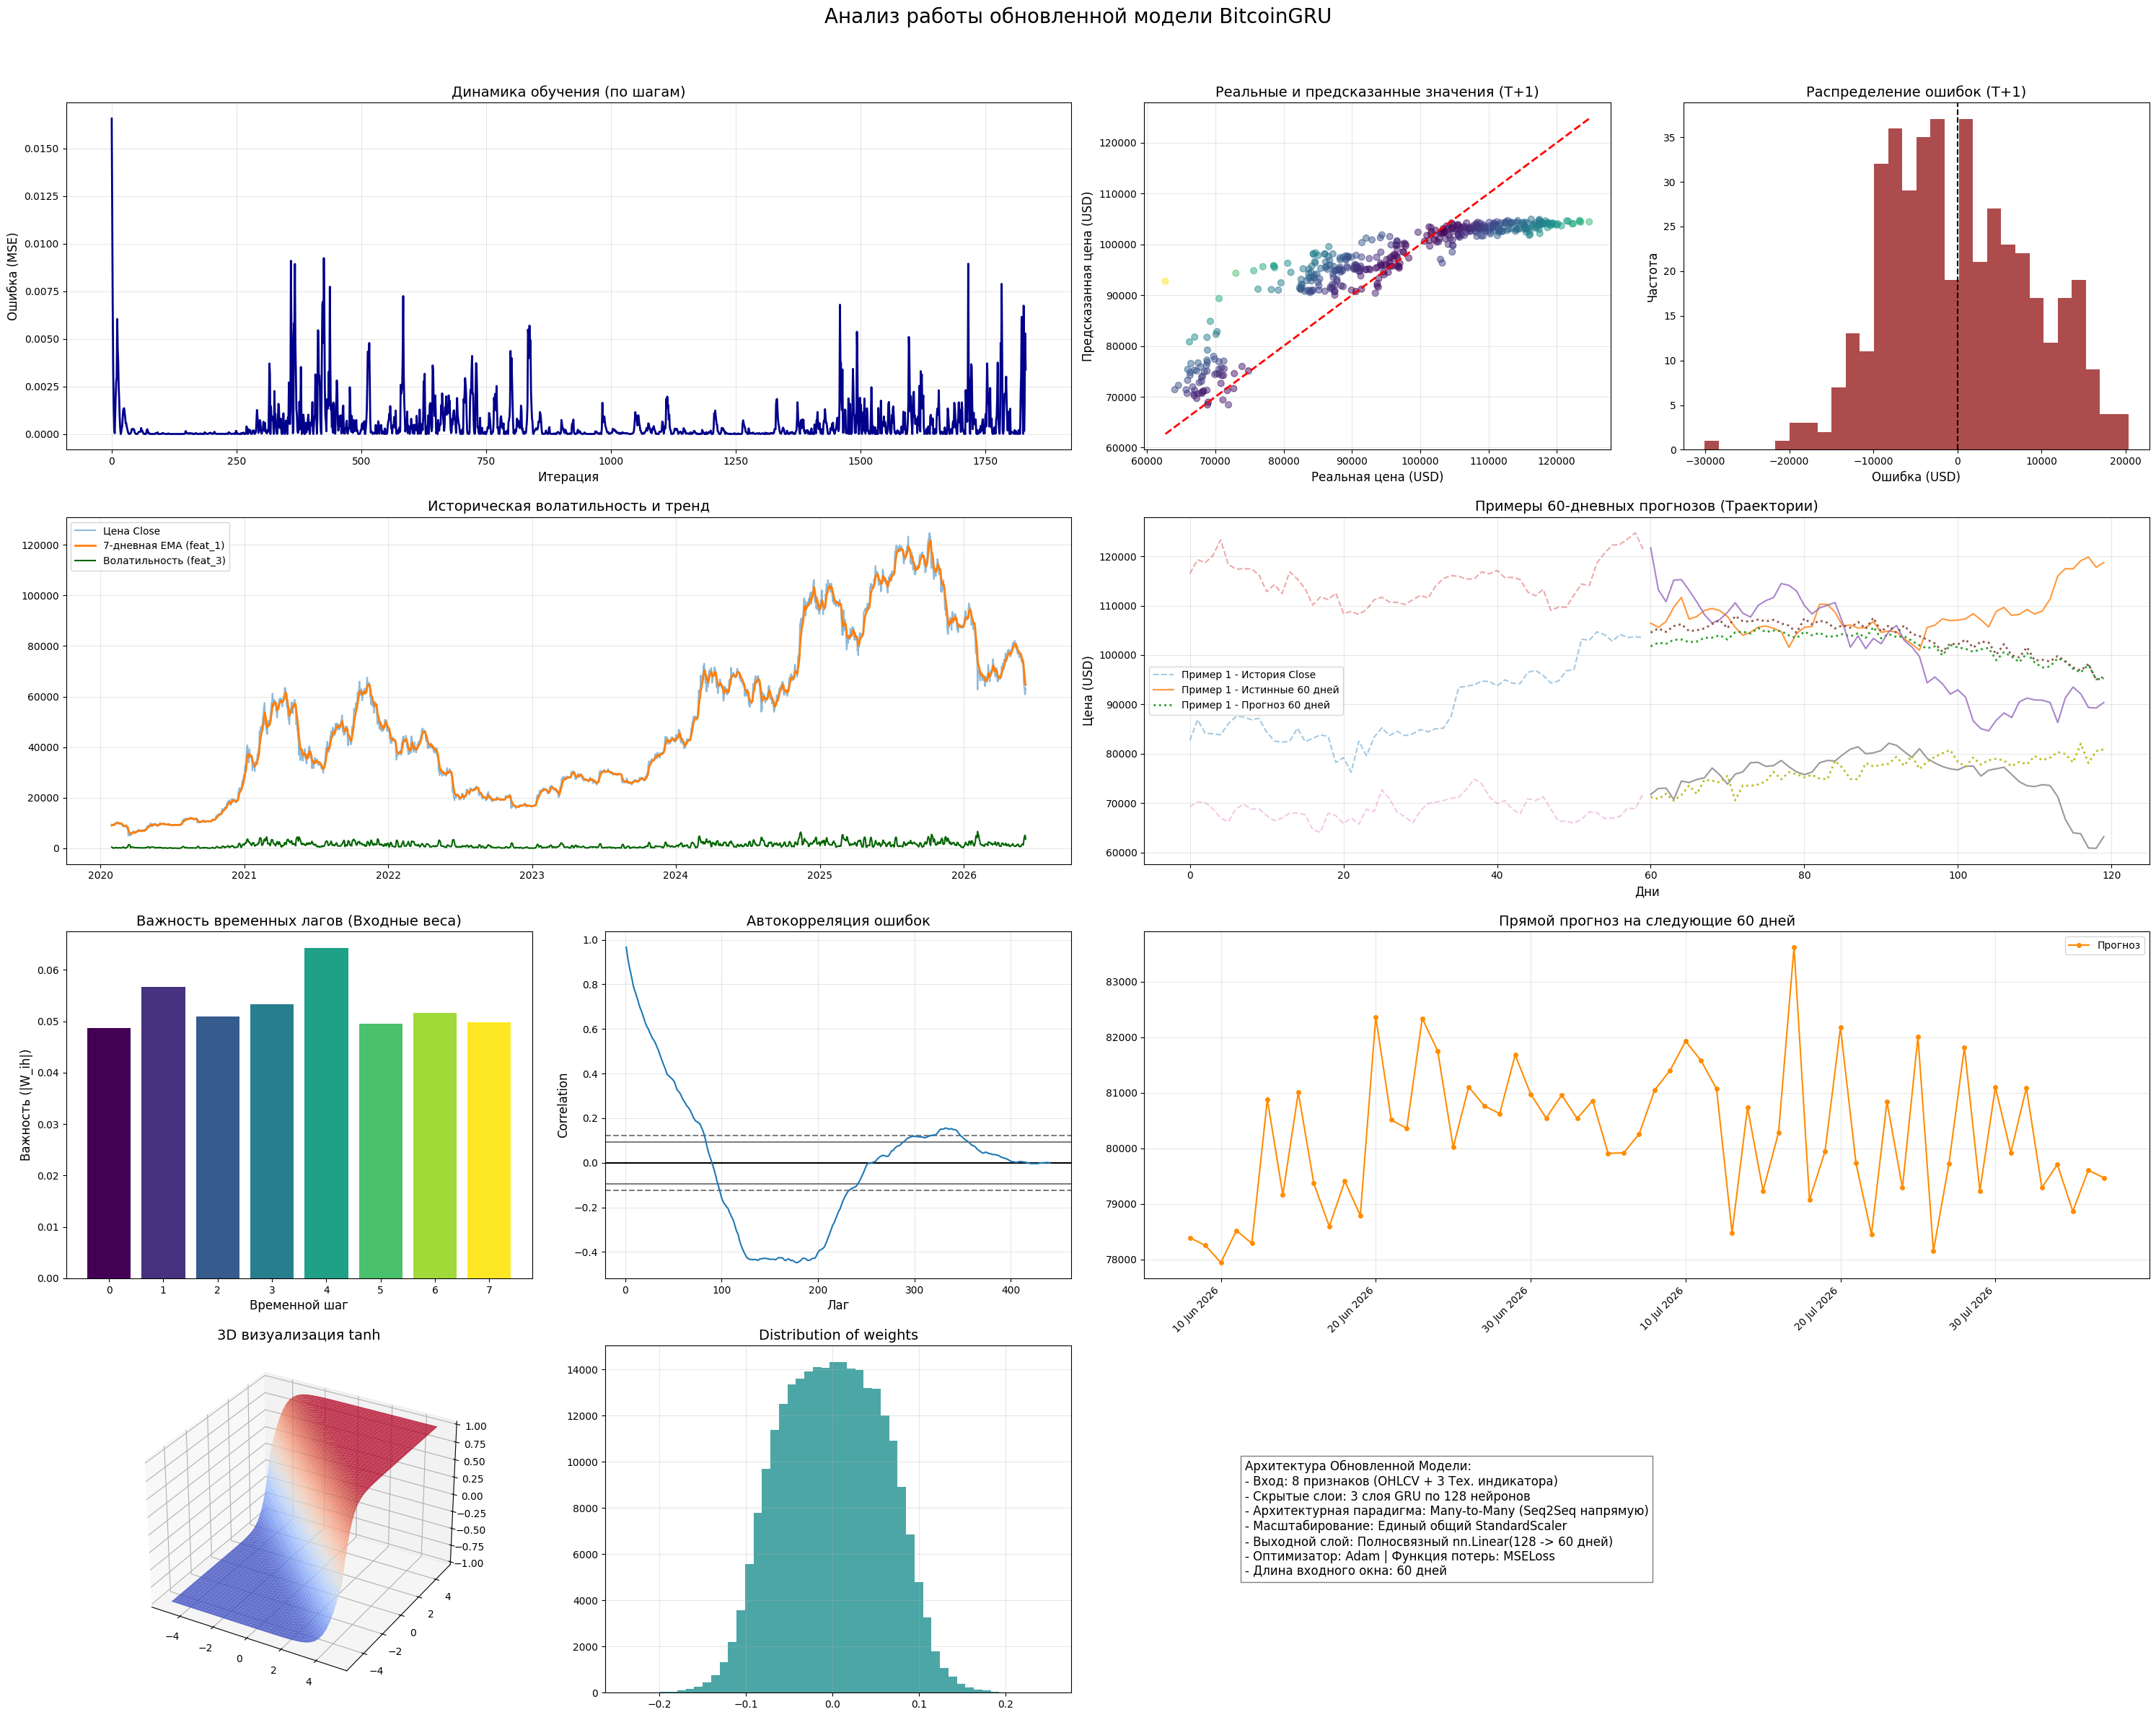

In [98]:
model.eval()


test_predictions_list = []
with torch.no_grad():
    for seq in X_test:
        pred = model(seq.unsqueeze(0).to('cuda'))
        test_predictions_list.append(pred.squeeze(0).cpu().numpy())


test_predictions = np.array(test_predictions_list)
y_test_numpy = y_test.numpy()


def inverse_transform_close(scaled_prices, scaler, close_idx=3, num_features=8):
    original_shape = scaled_prices.shape
    flat_prices = scaled_prices.flatten()
    dummy_matrix = np.zeros((len(flat_prices), num_features))
    dummy_matrix[:, close_idx] = flat_prices
    unscaled_matrix = scaler.inverse_transform(dummy_matrix)
    return unscaled_matrix[:, close_idx].reshape(original_shape)


y_test_original = inverse_transform_close(y_test_numpy, scaler)
test_predictions_orig = inverse_transform_close(test_predictions, scaler)

y_test_orig_flat = y_test_original[:, 0]
test_pred_flat = test_predictions_orig[:, 0]
errors = y_test_orig_flat - test_pred_flat

last_sequence = scaled_data[-seq_length:]
input_tensor = torch.FloatTensor(last_sequence).unsqueeze(0).to('cuda')

with torch.no_grad():
    scaled_forecast = model(input_tensor).squeeze(0).cpu().numpy()

forecast_prices = inverse_transform_close(scaled_forecast, scaler).flatten()

plt.figure(figsize = (30, 25))
plt.suptitle("Анализ работы обновленной модели BitcoinGRU", y = 0.95, fontsize = 20)

# 1. График обучения
ax1 = plt.subplot2grid((4, 4), (0, 0), colspan = 2)
ax1.plot(loss_arr, color = "darkblue", linewidth = 2)
ax1.set_title("Динамика обучения (по шагам)", fontsize = 14)
ax1.set_xlabel("Итерация", fontsize = 12)
ax1.set_ylabel("Ошибка (MSE)", fontsize = 12)
ax1.grid(True, alpha = 0.3)

# 2. Сравнение реальных и предсказанных значений (Т+1)
ax2 = plt.subplot2grid((4, 4), (0, 2))
ax2.scatter(y_test_orig_flat, test_pred_flat, alpha = 0.5, c = np.abs(errors), cmap = "viridis", s = 40)
ax2.plot([y_test_orig_flat.min(), y_test_orig_flat.max()], [y_test_orig_flat.min(), y_test_orig_flat.max()], "--r", linewidth = 2)
ax2.set_title("Реальные и предсказанные значения (T+1)", fontsize = 14)
ax2.set_xlabel("Реальная цена (USD)", fontsize = 12)
ax2.set_ylabel("Предсказанная цена (USD)", fontsize = 12)
ax2.grid(alpha = 0.3)

# 3. Распределение ошибок
ax3 = plt.subplot2grid((4, 4), (0, 3))
ax3.hist(errors, bins = 30, color = "darkred", alpha = 0.7)
ax3.set_title("Распределение ошибок (T+1)", fontsize = 14)
ax3.set_xlabel("Ошибка (USD)", fontsize = 12)
ax3.set_ylabel("Частота", fontsize = 12)
ax3.axvline(x = 0, color = "black", linestyle = "--")

# 4. Историческая волатильность и тренд (на основе исходного df)
ax4 = plt.subplot2grid((4, 4), (1, 0), colspan = 2)
ax4.plot(data.index, data["Close"], label = "Цена Close", alpha = 0.5)
ax4.plot(data.index, data["feat_1"], label = "7-дневная EMA (feat_1)", linewidth = 2)
ax4.plot(data.index, data["feat_3"], label = "Волатильность (feat_3)", color = "darkgreen")
ax4.set_title("Историческая волатильность и тренд", fontsize = 14)
ax4.legend()
ax4.grid(alpha = 0.3)

# 5. Примеры 60-дневных прогнозов (Траектории)
ax5 = plt.subplot2grid((4, 4), (1, 2), colspan = 2)
for i in range(3):
    idx = np.random.randint(len(X_test))

    seq_scaled = X_test[idx].numpy()  # Форма [60, 8]
    seq_close_scaled = seq_scaled[:, 3] # Достаем только Close (индекс 3)

    seq_real = inverse_transform_close(seq_close_scaled, scaler).flatten()
    real_future = y_test_original[idx]
    pred_future = test_predictions_orig[idx]

    time_history = range(len(seq_real))
    time_future = range(len(seq_real), len(seq_real) + len(real_future))

    ax5.plot(time_history, seq_real, alpha = 0.4, linestyle = "--", label = f"Пример {i+1} - История Close" if i==0 else "")
    ax5.plot(time_future, real_future, alpha = 0.8, label = f"Пример {i+1} - Истинные 60 дней" if i==0 else "")
    ax5.plot(time_future, pred_future, linestyle = ":", linewidth = 2, label = f"Пример {i+1} - Прогноз 60 дней" if i==0 else "")

ax5.set_title("Примеры 60-дневных прогнозов (Траектории)", fontsize = 14)
ax5.set_xlabel("Дни", fontsize = 12)
ax5.set_ylabel("Цена (USD)", fontsize = 12)
ax5.legend()
ax5.grid(alpha = 0.3)

# 6. Важность временных лагов
ax6 = plt.subplot2grid((4, 4), (2, 0))
gru_weights = np.abs(model.gru.weight_ih_l0.detach().cpu().numpy())
feature_importance = np.mean(gru_weights, axis = 0)

ax6.bar(range(len(feature_importance)), feature_importance, color = plt.cm.viridis(np.linspace(0, 1, len(feature_importance))))
ax6.set_title("Важность временных лагов (Входные веса)", fontsize = 14)
ax6.set_xlabel("Временной шаг", fontsize = 12)
ax6.set_ylabel("Важность (|W_ih|)", fontsize = 12)

# 7. Автокорреляция ошибок
ax7 = plt.subplot2grid((4, 4), (2, 1))
pd.plotting.autocorrelation_plot(errors.flatten(), ax = ax7)
ax7.set_title("Автокорреляция ошибок", fontsize = 14)
ax7.set_xlabel("Лаг", fontsize = 12)
ax7.set_ylabel("Correlation", fontsize = 12)
ax7.grid(alpha = 0.3)

# 8. Прямой прогноз на следующие 60 дней дат
ax8 = plt.subplot2grid((4, 4), (2, 2), colspan = 2)
forecast_dates = pd.date_range(start = data.index[-1], periods = len(forecast_prices) + 1)[1:]
ax8.plot(forecast_dates, forecast_prices, marker = "o", markersize = 4, linestyle = "-", color = "darkorange", label="Прогноз")
ax8.set_title("Прямой прогноз на следующие 60 дней", fontsize = 14)
ax8.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
ax8.xaxis.set_major_locator(mdates.DayLocator(interval = 10))
plt.setp(ax8.get_xticklabels(), rotation = 45, ha = "right")
ax8.legend()
ax8.grid(True, alpha = 0.3)

# 9. 3D визуализация функции activation
ax9 = plt.subplot2grid((4, 4), (3, 0), projection = "3d")
x = np.linspace(-5, 5, 50)
y = np.linspace(-5, 5, 50)
X, Y = np.meshgrid(x, y)
Z = np.tanh(X + Y)
ax9.plot_surface(X, Y, Z, cmap = "coolwarm", alpha = 0.8)
ax9.set_title("3D визуализация tanh", fontsize = 14)

# 10. Распределение весов модели
ax10 = plt.subplot2grid((4, 4), (3, 1))
all_weights = [param.detach().cpu().numpy().flatten() for param in model.parameters() if param.requires_grad]
ax10.hist(np.concatenate(all_weights), bins = 50, color = "teal", alpha = 0.7)
ax10.set_title("Distribution of weights", fontsize = 14)
ax10.grid(True, alpha = 0.3)

# 11. Легенда модели
ax11 = plt.subplot2grid((4, 4), (3, 2), colspan = 2)
ax11.axis("off")
text = f"""Архитектура Обновленной Модели:
- Вход: {model.input_size} признаков (OHLCV + 3 Тех. индикатора)
- Скрытые слои: {model.num_layers} слоя GRU по {model.hidden_size} нейронов
- Архитектурная парадигма: Many-to-Many (Seq2Seq напрямую)
- Масштабирование: Единый общий StandardScaler
- Выходной слой: Полносвязный nn.Linear({model.hidden_size} -> 60 дней)
- Оптимизатор: Adam | Функция потерь: MSELoss
- Длина входного окна: {seq_length} дней"""
ax11.text(0.1, 0.5, text, fontsize = 12, va = "center", bbox = dict(facecolor = "white", alpha = 0.5))

plt.tight_layout(rect = [0, 0, 1, 0.93])
plt.show()


Какие-то улучшения действительно наблюдаются, но всё ещё предсказательная способность не находится на должном уровне.

#### Попробуем теперь сильное упрощение, что нам нужно предсказывать не следующие 2 месяца, а следующие 14 дней. Этого должно быть достаточно, чтобы модель не переобучилась, предсказывывая, например, 3 дня, и чтобы она смогла что-то предсказать, раз не справилась на горизонте в 2 месяца.

In [99]:
from sklearn.preprocessing import StandardScaler
ticker = "BTC-USD"
data = yf.download(ticker, start = "2020-01-01", end=pd.Timestamp.now().strftime("%Y-%m-%d"))
data.columns = data.columns.get_level_values(0)
data['feat_1'] = data['Close'].ewm(span=7, adjust=False).mean()
data['feat_2'] = data['Close'].rolling(window=30).mean()
data['feat_3'] = data['Close'].rolling(window=7).std()
data = data.dropna()
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
scaled_data, data.columns

seq_length = 14
prediction_length = 14

X, y = create_sequences(scaled_data, seq_length, prediction_length, 0)
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
X_train.shape, y_train.shape


[*********************100%***********************]  1 of 1 completed


(torch.Size([1835, 14, 8]), torch.Size([1835, 14]))

In [102]:
class BitcoinGRUNew(nn.Module):
  def __init__(self, input_size = 8, hidden_size = 128, num_layers = 3):
    super(BitcoinGRUNew, self).__init__()
    self.input_size = input_size
    self.hidden_size = hidden_size
    self.num_layers = num_layers

    self.gru = nn.GRU(input_size = input_size,
                      hidden_size = hidden_size,
                      num_layers= num_layers,
                      batch_first = True)
    self.fc = nn.Linear(in_features=hidden_size, out_features=14).to('cuda')

  def forward(self, x):
    h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).requires_grad_().to('cuda')
    out, hn = self.gru(x, h0.detach())
    out = self.fc(out[:, -1, :])
    return out


In [105]:
model = BitcoinGRUNew().to('cuda')
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.00001)

num_epochs = 80
train_loss = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for i in range(len(X_train)):
        inputs = X_train[i].unsqueeze(0).to('cuda')
        target = y_train[i].unsqueeze(0).to('cuda')

        optimizer.zero_grad()
        output = model(inputs)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(X_train)
    train_loss.append(avg_loss)

    print(f'Epoch {epoch+1} / {num_epochs}, Loss: {avg_loss:.6f}')

Epoch 1 / 80, Loss: 0.258578
Epoch 2 / 80, Loss: 0.029055
Epoch 3 / 80, Loss: 0.026999
Epoch 4 / 80, Loss: 0.026287
Epoch 5 / 80, Loss: 0.025509
Epoch 6 / 80, Loss: 0.024636
Epoch 7 / 80, Loss: 0.023784
Epoch 8 / 80, Loss: 0.023003
Epoch 9 / 80, Loss: 0.022303
Epoch 10 / 80, Loss: 0.021678
Epoch 11 / 80, Loss: 0.021122
Epoch 12 / 80, Loss: 0.020627
Epoch 13 / 80, Loss: 0.020182
Epoch 14 / 80, Loss: 0.019784
Epoch 15 / 80, Loss: 0.019428
Epoch 16 / 80, Loss: 0.019109
Epoch 17 / 80, Loss: 0.018823
Epoch 18 / 80, Loss: 0.018565
Epoch 19 / 80, Loss: 0.018331
Epoch 20 / 80, Loss: 0.018117
Epoch 21 / 80, Loss: 0.017921
Epoch 22 / 80, Loss: 0.017739
Epoch 23 / 80, Loss: 0.017570
Epoch 24 / 80, Loss: 0.017411
Epoch 25 / 80, Loss: 0.017262
Epoch 26 / 80, Loss: 0.017122
Epoch 27 / 80, Loss: 0.016989
Epoch 28 / 80, Loss: 0.016862
Epoch 29 / 80, Loss: 0.016742
Epoch 30 / 80, Loss: 0.016628
Epoch 31 / 80, Loss: 0.016519
Epoch 32 / 80, Loss: 0.016415
Epoch 33 / 80, Loss: 0.016315
Epoch 34 / 80, Loss

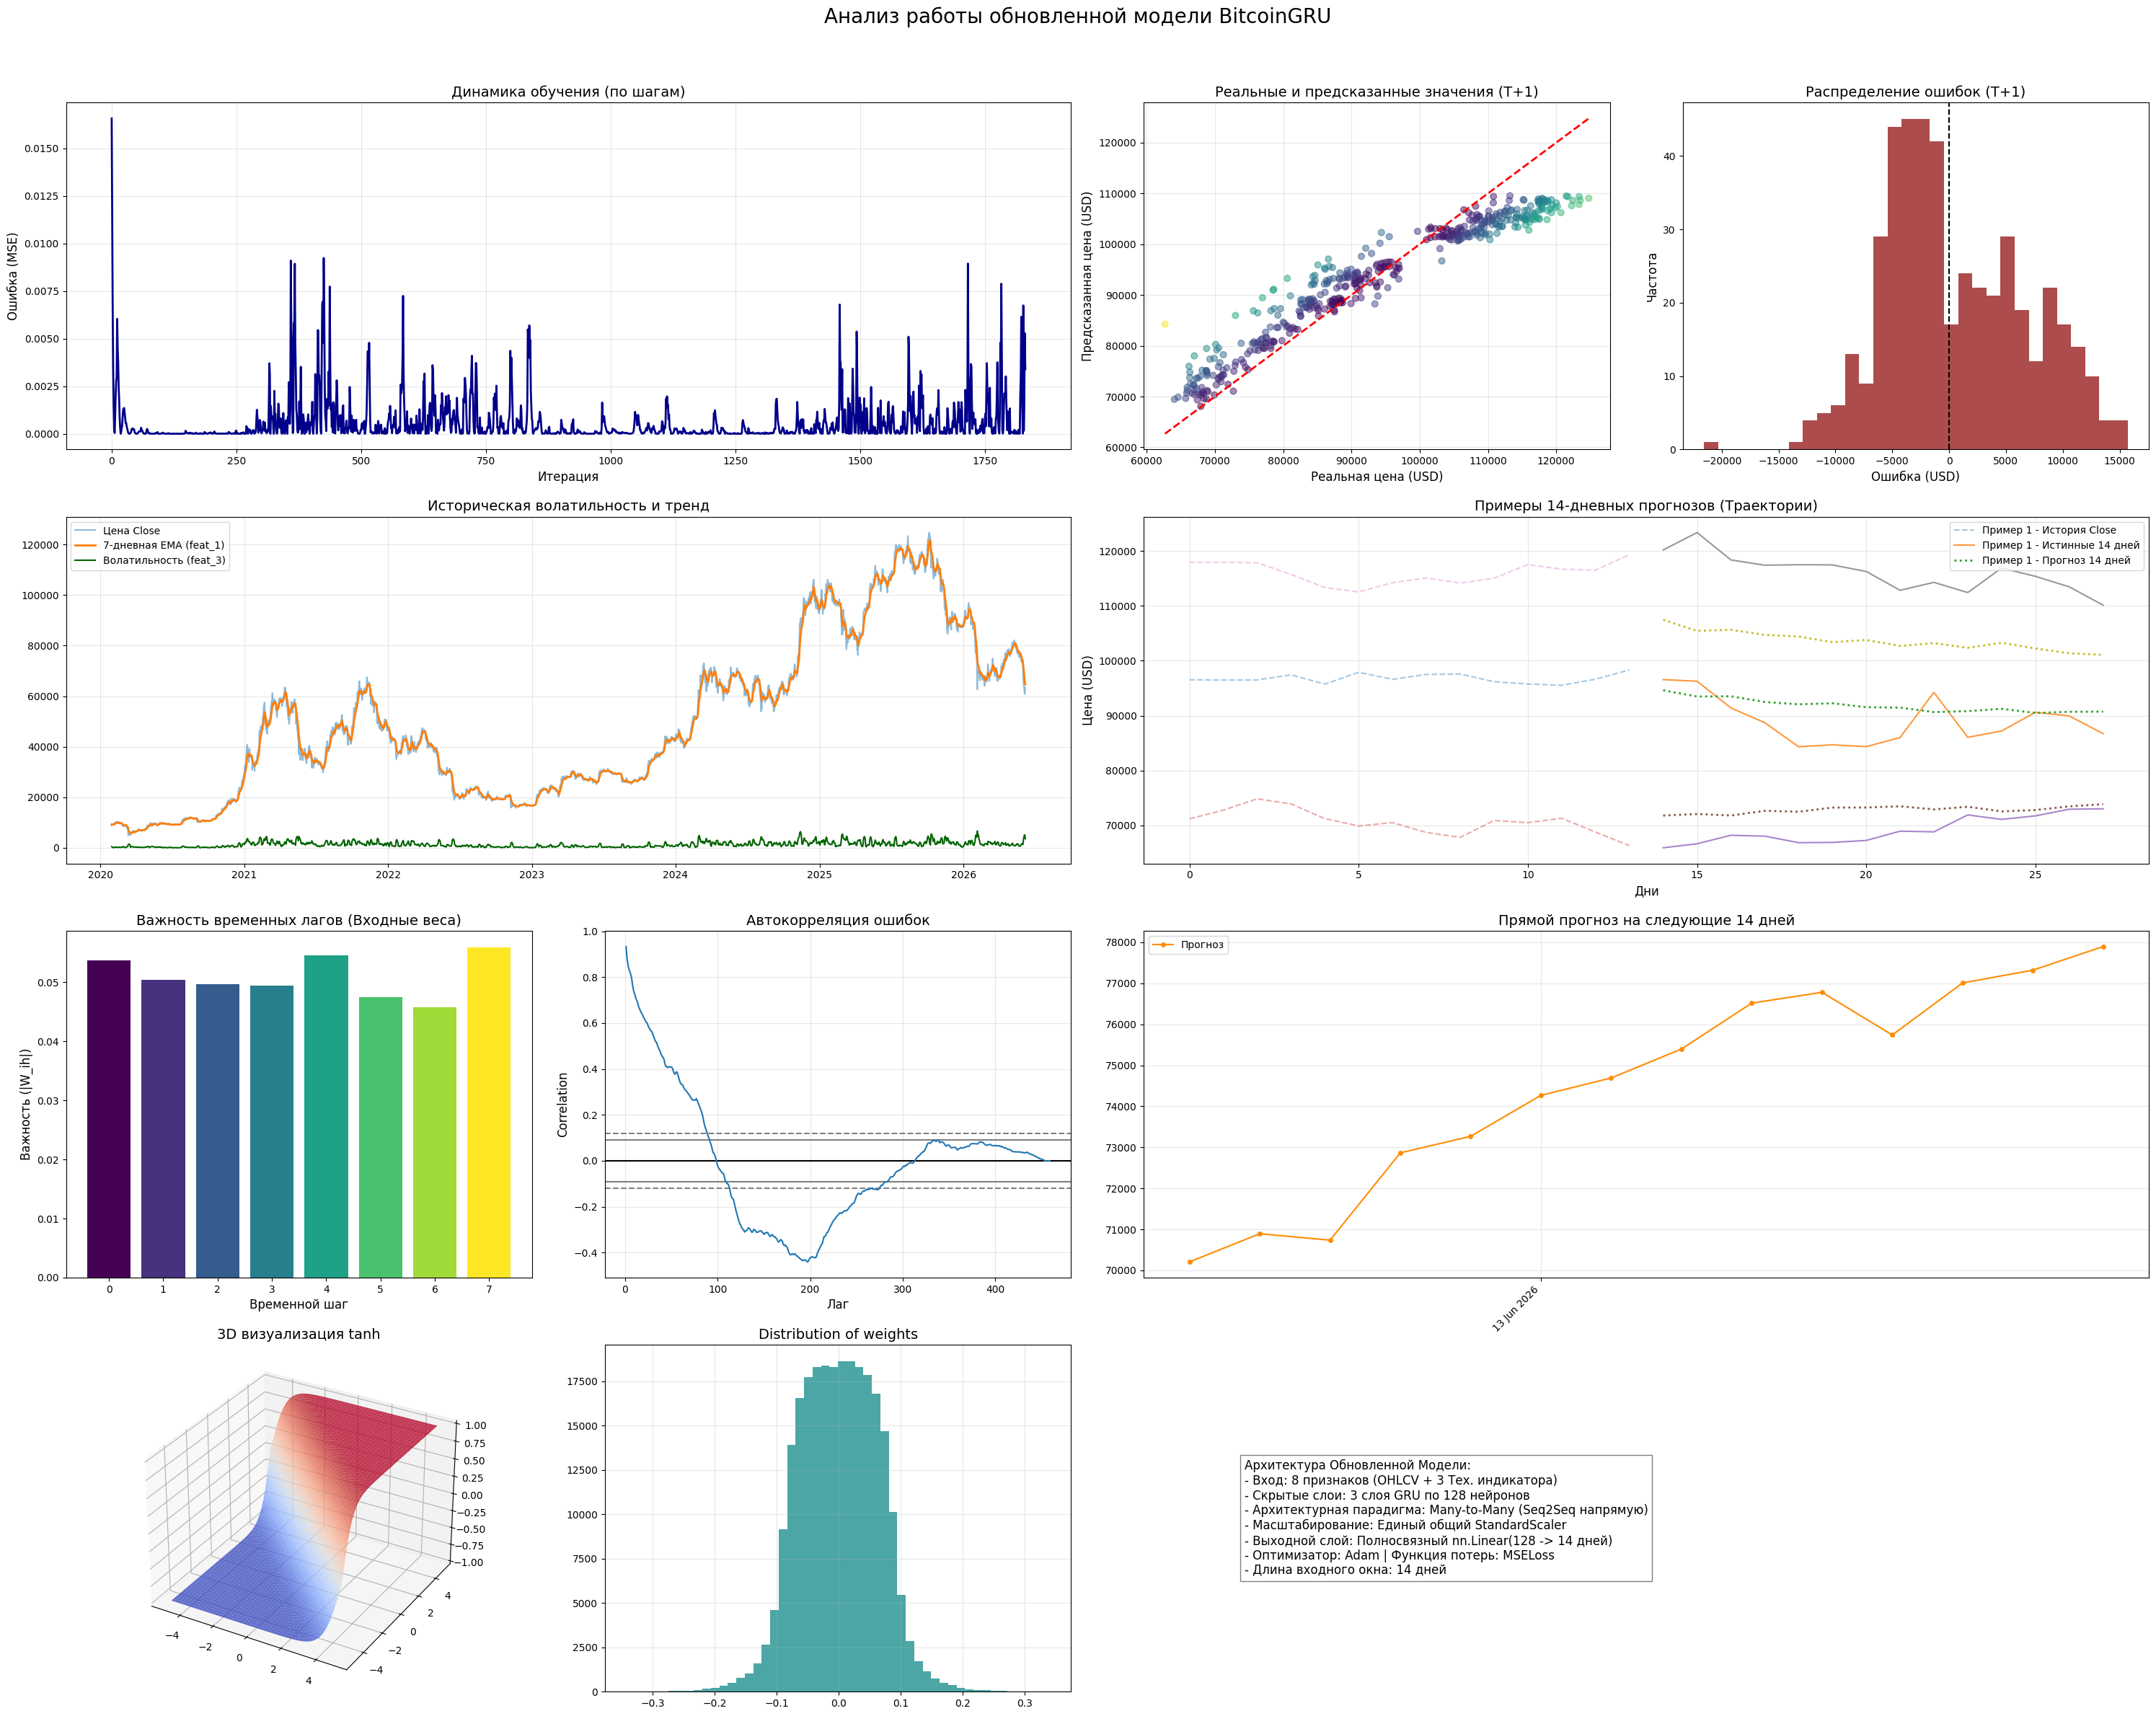

In [108]:
model.eval()


test_predictions_list = []
with torch.no_grad():
    for seq in X_test:
        pred = model(seq.unsqueeze(0).to('cuda'))
        test_predictions_list.append(pred.squeeze(0).cpu().numpy())


test_predictions = np.array(test_predictions_list)
y_test_numpy = y_test.numpy()


def inverse_transform_close(scaled_prices, scaler, close_idx=3, num_features=8):
    original_shape = scaled_prices.shape
    flat_prices = scaled_prices.flatten()
    dummy_matrix = np.zeros((len(flat_prices), num_features))
    dummy_matrix[:, close_idx] = flat_prices
    unscaled_matrix = scaler.inverse_transform(dummy_matrix)
    return unscaled_matrix[:, close_idx].reshape(original_shape)


y_test_original = inverse_transform_close(y_test_numpy, scaler)
test_predictions_orig = inverse_transform_close(test_predictions, scaler)

y_test_orig_flat = y_test_original[:, 0]
test_pred_flat = test_predictions_orig[:, 0]
errors = y_test_orig_flat - test_pred_flat

last_sequence = scaled_data[-seq_length:]
input_tensor = torch.FloatTensor(last_sequence).unsqueeze(0).to('cuda')

with torch.no_grad():
    scaled_forecast = model(input_tensor).squeeze(0).cpu().numpy()

forecast_prices = inverse_transform_close(scaled_forecast, scaler).flatten()

plt.figure(figsize = (30, 25))
plt.suptitle("Анализ работы обновленной модели BitcoinGRU", y = 0.95, fontsize = 20)

# 1. График обучения
ax1 = plt.subplot2grid((4, 4), (0, 0), colspan = 2)
ax1.plot(loss_arr, color = "darkblue", linewidth = 2)
ax1.set_title("Динамика обучения (по шагам)", fontsize = 14)
ax1.set_xlabel("Итерация", fontsize = 12)
ax1.set_ylabel("Ошибка (MSE)", fontsize = 12)
ax1.grid(True, alpha = 0.3)

# 2. Сравнение реальных и предсказанных значений (Т+1)
ax2 = plt.subplot2grid((4, 4), (0, 2))
ax2.scatter(y_test_orig_flat, test_pred_flat, alpha = 0.5, c = np.abs(errors), cmap = "viridis", s = 40)
ax2.plot([y_test_orig_flat.min(), y_test_orig_flat.max()], [y_test_orig_flat.min(), y_test_orig_flat.max()], "--r", linewidth = 2)
ax2.set_title("Реальные и предсказанные значения (T+1)", fontsize = 14)
ax2.set_xlabel("Реальная цена (USD)", fontsize = 12)
ax2.set_ylabel("Предсказанная цена (USD)", fontsize = 12)
ax2.grid(alpha = 0.3)

# 3. Распределение ошибок
ax3 = plt.subplot2grid((4, 4), (0, 3))
ax3.hist(errors, bins = 30, color = "darkred", alpha = 0.7)
ax3.set_title("Распределение ошибок (T+1)", fontsize = 14)
ax3.set_xlabel("Ошибка (USD)", fontsize = 12)
ax3.set_ylabel("Частота", fontsize = 12)
ax3.axvline(x = 0, color = "black", linestyle = "--")

# 4. Историческая волатильность и тренд (на основе исходного df)
ax4 = plt.subplot2grid((4, 4), (1, 0), colspan = 2)
ax4.plot(data.index, data["Close"], label = "Цена Close", alpha = 0.5)
ax4.plot(data.index, data["feat_1"], label = "7-дневная EMA (feat_1)", linewidth = 2)
ax4.plot(data.index, data["feat_3"], label = "Волатильность (feat_3)", color = "darkgreen")
ax4.set_title("Историческая волатильность и тренд", fontsize = 14)
ax4.legend()
ax4.grid(alpha = 0.3)

# 5. Примеры 14-дневных прогнозов (Траектории)
ax5 = plt.subplot2grid((4, 4), (1, 2), colspan = 2)
for i in range(3):
    idx = np.random.randint(len(X_test))

    seq_scaled = X_test[idx].numpy()
    seq_close_scaled = seq_scaled[:, 3]

    seq_real = inverse_transform_close(seq_close_scaled, scaler).flatten()
    real_future = y_test_original[idx]
    pred_future = test_predictions_orig[idx]

    time_history = range(len(seq_real))
    time_future = range(len(seq_real), len(seq_real) + len(real_future))

    ax5.plot(time_history, seq_real, alpha = 0.4, linestyle = "--", label = f"Пример {i+1} - История Close" if i==0 else "")
    ax5.plot(time_future, real_future, alpha = 0.8, label = f"Пример {i+1} - Истинные 14 дней" if i==0 else "")
    ax5.plot(time_future, pred_future, linestyle = ":", linewidth = 2, label = f"Пример {i+1} - Прогноз 14 дней" if i==0 else "")

ax5.set_title("Примеры 14-дневных прогнозов (Траектории)", fontsize = 14)
ax5.set_xlabel("Дни", fontsize = 12)
ax5.set_ylabel("Цена (USD)", fontsize = 12)
ax5.legend()
ax5.grid(alpha = 0.3)

# 6. Важность временных лагов
ax6 = plt.subplot2grid((4, 4), (2, 0))
gru_weights = np.abs(model.gru.weight_ih_l0.detach().cpu().numpy())
feature_importance = np.mean(gru_weights, axis = 0)

ax6.bar(range(len(feature_importance)), feature_importance, color = plt.cm.viridis(np.linspace(0, 1, len(feature_importance))))
ax6.set_title("Важность временных лагов (Входные веса)", fontsize = 14)
ax6.set_xlabel("Временной шаг", fontsize = 12)
ax6.set_ylabel("Важность (|W_ih|)", fontsize = 12)

# 7. Автокорреляция ошибок
ax7 = plt.subplot2grid((4, 4), (2, 1))
pd.plotting.autocorrelation_plot(errors.flatten(), ax = ax7)
ax7.set_title("Автокорреляция ошибок", fontsize = 14)
ax7.set_xlabel("Лаг", fontsize = 12)
ax7.set_ylabel("Correlation", fontsize = 12)
ax7.grid(alpha = 0.3)

# 8. Прямой прогноз на следующие 14 дней дат
ax8 = plt.subplot2grid((4, 4), (2, 2), colspan = 2)
forecast_dates = pd.date_range(start = data.index[-1], periods = len(forecast_prices) + 1)[1:]
ax8.plot(forecast_dates, forecast_prices, marker = "o", markersize = 4, linestyle = "-", color = "darkorange", label="Прогноз")
ax8.set_title("Прямой прогноз на следующие 14 дней", fontsize = 14)
ax8.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
ax8.xaxis.set_major_locator(mdates.DayLocator(interval = 10))
plt.setp(ax8.get_xticklabels(), rotation = 45, ha = "right")
ax8.legend()
ax8.grid(True, alpha = 0.3)

# 9. 3D визуализация функции activation
ax9 = plt.subplot2grid((4, 4), (3, 0), projection = "3d")
x = np.linspace(-5, 5, 50)
y = np.linspace(-5, 5, 50)
X, Y = np.meshgrid(x, y)
Z = np.tanh(X + Y)
ax9.plot_surface(X, Y, Z, cmap = "coolwarm", alpha = 0.8)
ax9.set_title("3D визуализация tanh", fontsize = 14)

# 10. Распределение весов модели
ax10 = plt.subplot2grid((4, 4), (3, 1))
all_weights = [param.detach().cpu().numpy().flatten() for param in model.parameters() if param.requires_grad]
ax10.hist(np.concatenate(all_weights), bins = 50, color = "teal", alpha = 0.7)
ax10.set_title("Distribution of weights", fontsize = 14)
ax10.grid(True, alpha = 0.3)

# 11. Легенда модели
ax11 = plt.subplot2grid((4, 4), (3, 2), colspan = 2)
ax11.axis("off")
text = f"""Архитектура Обновленной Модели:
- Вход: {model.input_size} признаков (OHLCV + 3 Тех. индикатора)
- Скрытые слои: {model.num_layers} слоя GRU по {model.hidden_size} нейронов
- Архитектурная парадигма: Many-to-Many (Seq2Seq напрямую)
- Масштабирование: Единый общий StandardScaler
- Выходной слой: Полносвязный nn.Linear({model.hidden_size} -> 14 дней)
- Оптимизатор: Adam | Функция потерь: MSELoss
- Длина входного окна: {seq_length} дней"""
ax11.text(0.1, 0.5, text, fontsize = 12, va = "center", bbox = dict(facecolor = "white", alpha = 0.5))

plt.tight_layout(rect = [0, 0, 1, 0.93])
plt.show()


Стало получше модели на 60 дней, но всё ещё результаты не идеальные.

## Выводы.

Таким образом мы попробовали следующие изменения к оригинальному решению:
- **Изменение скейлера**. Важно правильно выбирать инструмент обработки данных, так как в нашем случае `MinMaxScaler` не очень подходил как минимум потому, что мы не могли адекватно сделать обратное преобразование, чтобы получить адекватное предсказание.
- **Произвели feature engineering**. Информации из `closure` было недостаточно для наших моделей, чтобы они хоть сколько-то адекватно предсказывали реальное положение дел. Поэтому мы взяли все столбцы, которые предоставляют нам `yfinance`, использовали их и сгенерировали на их основе ещё несколько признаков, которые были важны для предсказательной способности.
- **Попробовали изменения архитектуры**. Как минимум, мы увеличили количество слоёв и размерность внутреннего вектора памяти, что положительно сказалось на предсказательной способности.
- **Поменяли модель предсказаний**. Вместо предсказания следующего дня, мы стали предсказывать сразу T дней вперёд, что позволило уйти от того, что модель на своих же предсказаниях начинала выдавать неадекватные средние значения, убивающие весь смысл.
- **Поменяли параметры обучения**. Увеличи количество эпох и уменьшили шаг, так как при обучении было видно, что модель перескакивает минимум при большом шаге.
- **Уменьшили окно предсказаний**. Оказалось, что модели очень тяжело переносит большой горизонт планирования, так как при $T = 60$ предсказания модели были скорее неадекватны, а при $T = 14$ модель показала существенно лучший результат.

Такими способами мы боролись с основными проблемами, почему модель выдавала некорректные предсказания.